In [ ]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
import math

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
# Download latest version
dataSetName = "mexwell/social-conflict-analysis-database"
path = kagglehub.dataset_download(dataSetName)

print("Path to dataset files:", path)
csv_files = [file for file in os.listdir(path) if file.endswith('.csv')]
print("CSV Files:", csv_files)

100%|██████████| 2.25M/2.25M [00:00<00:00, 145MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mexwell/social-conflict-analysis-database/versions/1
CSV Files: ['SCAD2018LatinAmerica_Final.csv', 'SCAD2018Africa_Final.csv']


In [ ]:
filepath = f"{path}/{csv_files[0]}"
print(filepath)

/root/.cache/kagglehub/datasets/mexwell/social-conflict-analysis-database/versions/1/SCAD2018LatinAmerica_Final.csv


In [ ]:
df = pd.read_csv(filepath, sep=",", encoding='mac_roman')
df.head(50)

,eventid,id,ccode,countryname,startdate,enddate,duration,stday,stmo,styr,...,nsource,notes,female_event,lgbtq_issue,coder,acd_questionable,latitude,longitude,geo_comments,location_precision
0,400001,1,40,Cuba,28-Jan-90,28-Jan-90,1,28,1,1990,...,AP,NaN,0,0,MW,0,21.950001,-79.550003,Unknown location,no
1,400002,2,40,Cuba,5-Mar-90,5-Mar-90,1,5,3,1990,...,AP,NaN,0,0,MW,0,21.950001,-79.550003,Unknown location,no
2,400003,3,40,Cuba,8-Mar-90,8-Mar-90,1,8,3,1990,...,AP,NaN,0,0,MW,0,21.950001,-79.550003,Unknown location,no
3,400004,4,40,Cuba,9-Jul-90,26-Jul-90,18,9,7,1990,...,AP,Is asylum-seeking at embassies a codeable even...,0,0,MW,0,23.054070,-82.345192,NaN,NaN
4,400005,5,40,Cuba,17-Jul-90,17-Jul-90,1,17,7,1990,...,AP,Exact date not specified; event date approximated,0,0,MW,0,23.054070,-82.345192,NaN,NaN
5,400006,6,40,Cuba,26-Dec-90,26-Dec-90,1,26,12,1990,...,AP,NaN,0,0,MW,0,21.666670,-82.833344,Location set to center point of the island.,NaN
6,400007,7,40,Cuba,15-Nov-91,15-Nov-91,1,15,11,1991,...,Both,"Date not given, so estimated here.",0,0,MW,0,23.054070,-82.345192,NaN,NaN
7,400008,8,40,Cuba,9-Jan-92,9-Jan-92,1,9,1,1992,...,AP,Unclear if this is same event as one below.,0,0,MW,0,23.174509,-82.206703,NaN,NaN
8,400009,9,40,Cuba,11-Jan-92,11-Jan-92,1,11,1,1992,...,AP,"Date not given, so estimated here. Unclear if ...",0,0,MW,0,21.950001,-79.550003,Unknown location,no
9,400010,10,40,Cuba,16-Jan-92,16-Jan-92,1,16,1,1992,...,AP,NaN,0,0,MW,0,21.950001,-79.550003,Unknown location,no


In [ ]:
columns = list(df.columns)
print(columns)

['eventid', 'id', 'ccode', 'countryname', 'startdate', 'enddate', 'duration', 'stday', 'stmo', 'styr', 'eday', 'emo', 'eyr', 'etype', 'escalation', 'actor1', 'actor2', 'actor3', 'target1', 'target2', 'cgovtarget', 'rgovtarget', 'npart', 'ndeath', 'repress', 'elocal', 'ilocal', 'sublocal', 'locnum', 'gislocnum', 'issue1', 'issue2', 'issue3', 'issuenote', 'nsource', 'notes', 'female_event', 'lgbtq_issue', 'coder', 'acd_questionable', 'latitude', 'longitude', 'geo_comments', 'location_precision']


In [ ]:
df.dtypes

,0
eventid,int64
id,int64
ccode,int64
countryname,object
startdate,object
enddate,object
duration,int64
stday,int64
stmo,int64
styr,int64


In [ ]:
df.countryname.unique()

array(['Cuba', 'Haiti', 'Dominican Republic', 'Jamaica',
       'Trinidad and Tobago', 'Mexico', 'Guatemala', 'Honduras',
       'El Salvador', 'Nicaragua', 'Costa Rica', 'Panama'], dtype=object)

In [ ]:
dfCauses = df[['eventid', 'countryname', 'styr', 'etype', 'ndeath', 'repress', 'issue1', 'issuenote', 'actor1', 'actor2', 'actor3', 'target1', 'target2' ]].reset_index()

In [ ]:
dfConteoConflictos = df.groupby(['countryname','styr'])['eventid'].count().reset_index()

In [ ]:
dfConteoConflictos.head()

,countryname,styr,eventid
0,Costa Rica,1993,2
1,Costa Rica,1995,2
2,Costa Rica,1996,4
3,Costa Rica,1998,2
4,Costa Rica,1999,2


In [ ]:
dfConteoConflictos = dfConteoConflictos.reset_index()
dfConteoConflictos=dfConteoConflictos.rename(columns={'eventid':'conlictsPerYear', 'countryname':'Country', 'styr':'year'})

In [ ]:
dfConteoConflictos.head()

,index,Country,year,conlictsPerYear
0,0,Costa Rica,1993,2
1,1,Costa Rica,1995,2
2,2,Costa Rica,1996,4
3,3,Costa Rica,1998,2
4,4,Costa Rica,1999,2


In [ ]:
figure = px.scatter(dfConteoConflictos, x= "year", y="conlictsPerYear", color="Country", hover_name="Country")
figure.update_layout(
    title = "Numero de conlfictos por pais",
    xaxis_title="Año",
    yaxis_title="Numero de conflictos",
    legend_title="Country/Region"
)
filePathHtml = f"Conflictos_pais.html"
figure.write_html(filePathHtml)
figure.show()

In [ ]:
dfConteoConflictosMexico = dfConteoConflictos[dfConteoConflictos['Country']=='Mexico']

In [ ]:
figure = px.scatter(dfConteoConflictosMexico, x= "year", y="conlictsPerYear")
figure.update_layout(
    title = "Numero de conlfictos en Mexico",
    xaxis_title="Año",
    yaxis_title="Numero de conflictos"
)
filePathHtml = f"Conflictos_pais_Mexico.html"
figure.write_html(filePathHtml)
figure.show()

In [ ]:
countries = list(dfConteoConflictos.Country.unique())

In [ ]:
dfConteoConflictosperCountry = {}
for pais, df_pais in dfConteoConflictos.groupby('Country'):
    dfConteoConflictosperCountry[pais] = df_pais

In [ ]:
print(dfConteoConflictosperCountry['Costa Rica'])

    index     Country  year  conlictsPerYear
0       0  Costa Rica  1993                2
1       1  Costa Rica  1995                2
2       2  Costa Rica  1996                4
3       3  Costa Rica  1998                2
4       4  Costa Rica  1999                2
5       5  Costa Rica  2000                6
6       6  Costa Rica  2001                1
7       7  Costa Rica  2002                3
8       8  Costa Rica  2003                3
9       9  Costa Rica  2004                2
10     10  Costa Rica  2005                2
11     11  Costa Rica  2007                2
12     12  Costa Rica  2010                1
13     13  Costa Rica  2011                2
14     14  Costa Rica  2013                1
15     15  Costa Rica  2016                2
16     16  Costa Rica  2017                1


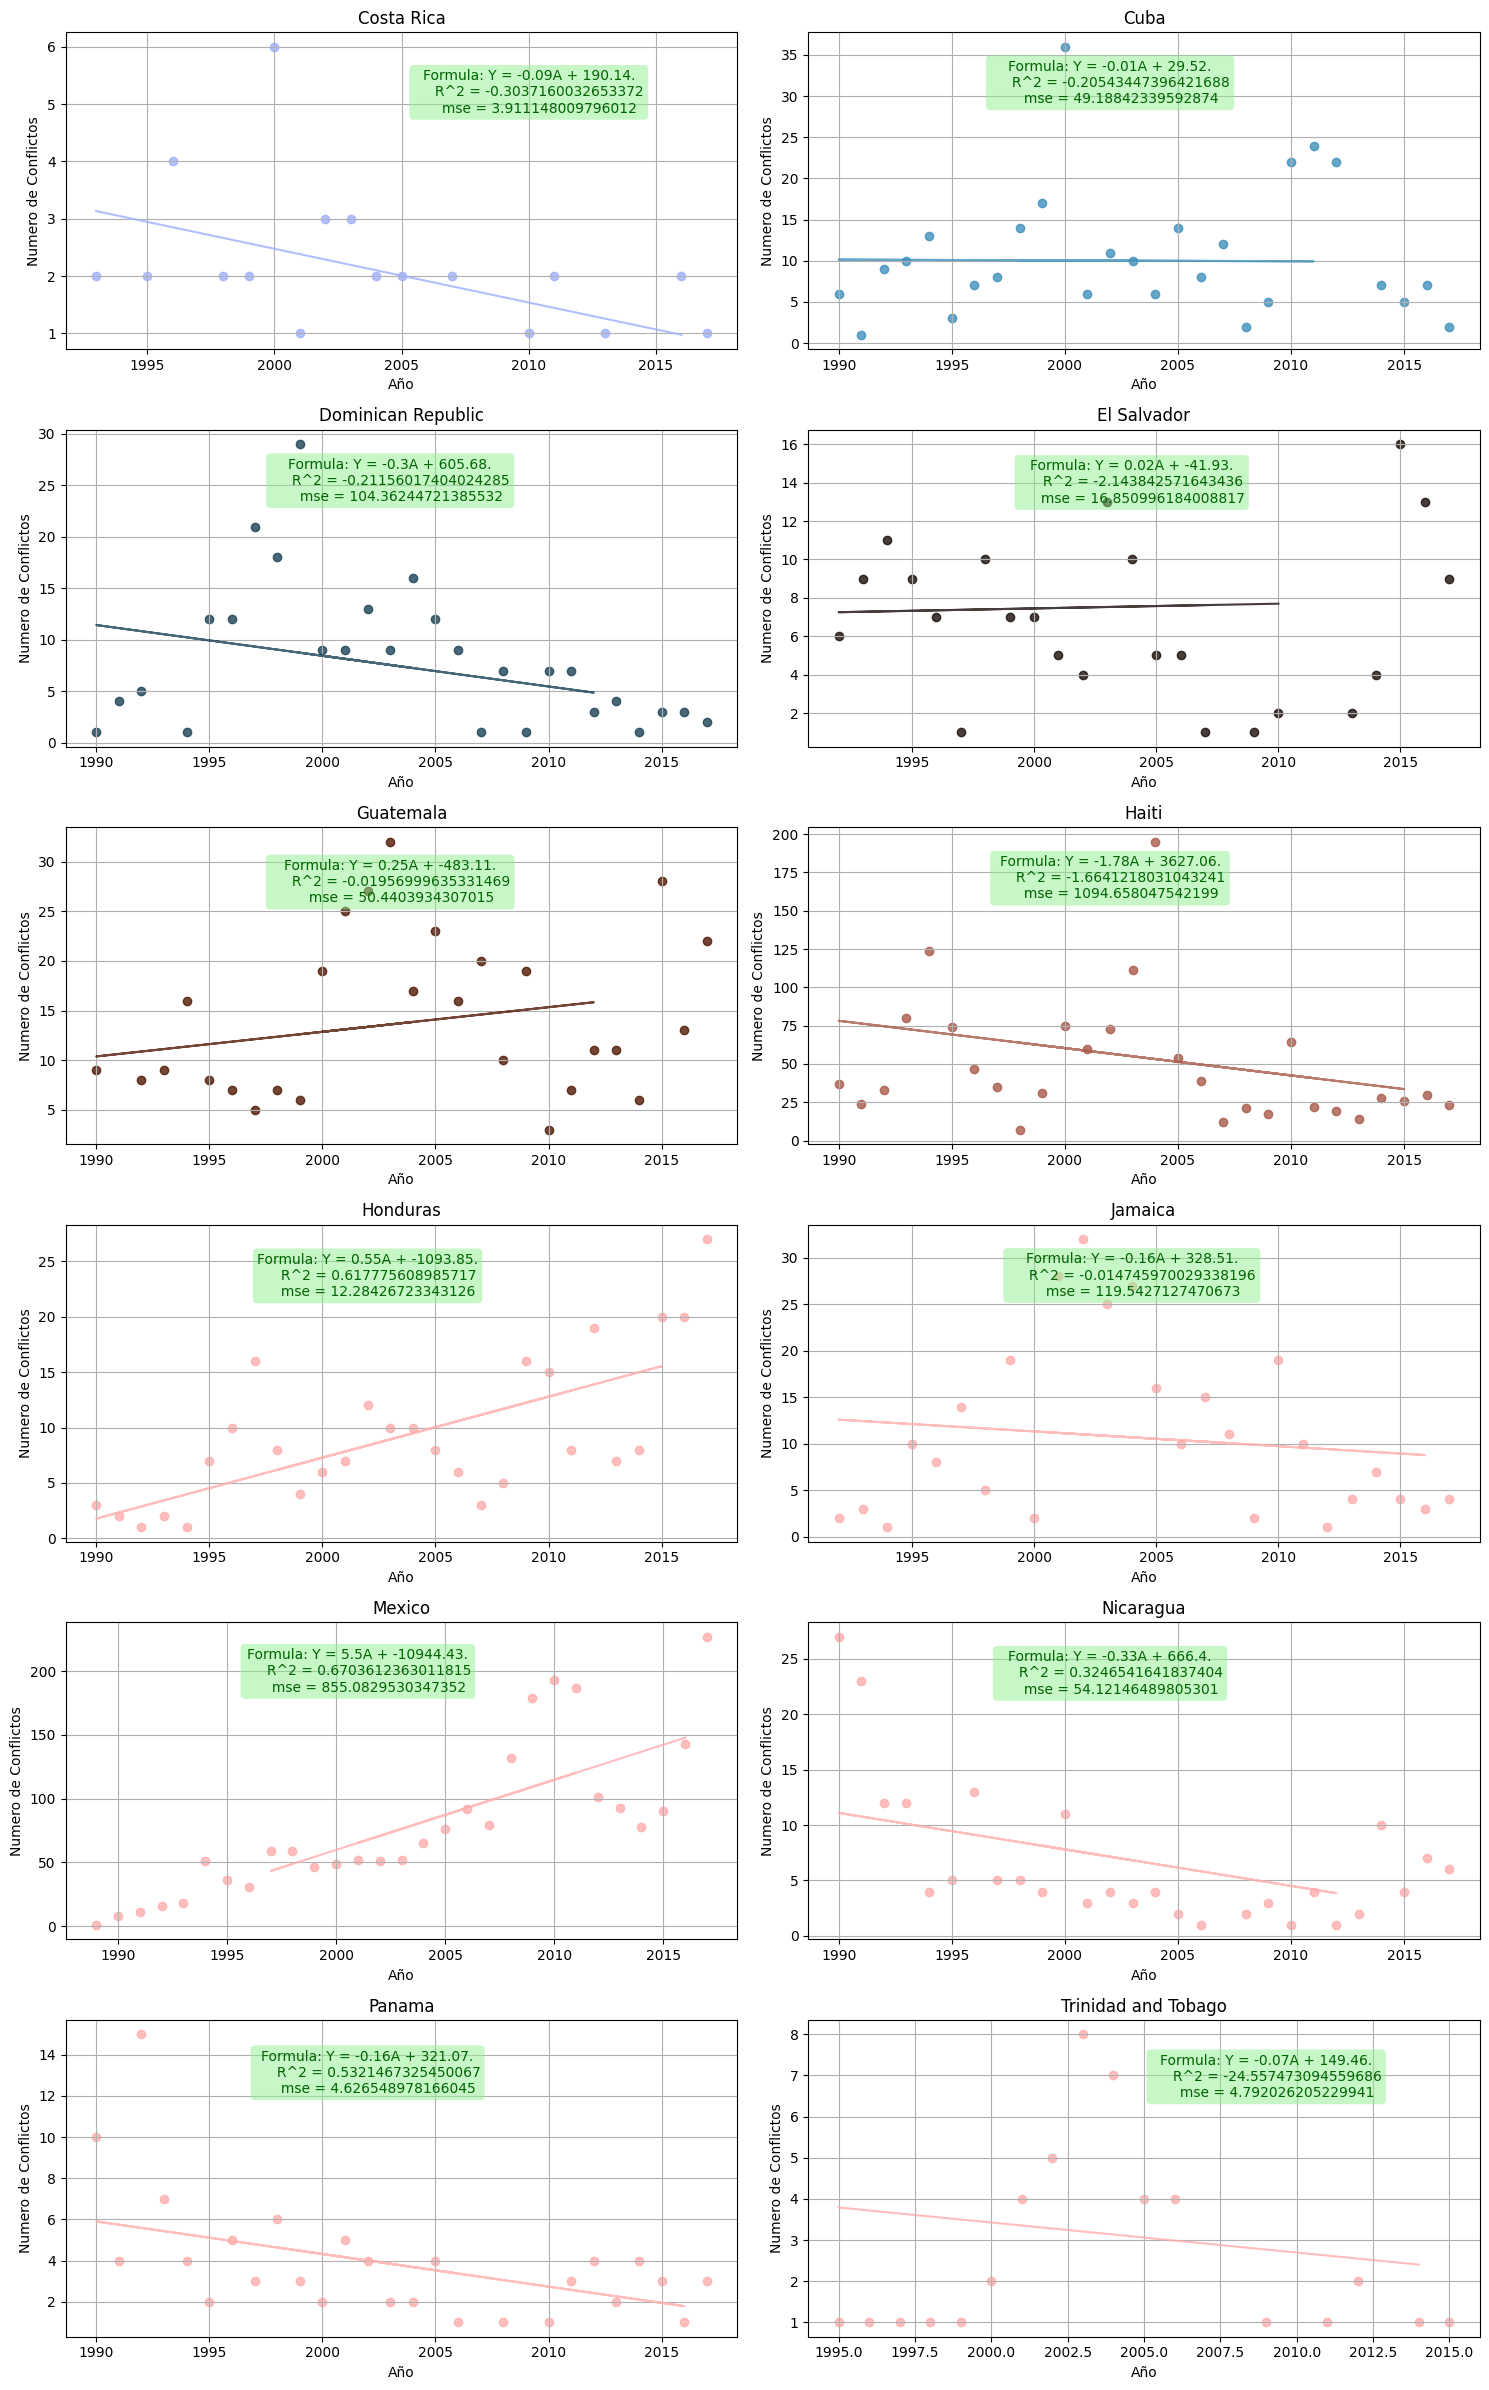

In [ ]:
qtyCountries = len(countries)
showplotsqtyCountries = math.ceil(qtyCountries / 2)
fig, axes = plt.subplots(showplotsqtyCountries, 2, figsize=(15, showplotsqtyCountries * 4))
axes = np.atleast_1d(axes).flatten()

for i, country in enumerate(countries):

  dftoPlot = dfConteoConflictosperCountry[country]
  X = dftoPlot[["year"]]
  y = dftoPlot['conlictsPerYear']

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


  modelo_regresion = LinearRegression()
  modelo_regresion.fit(X_train, y_train)

  coef = modelo_regresion.coef_[0]
  b = modelo_regresion.intercept_




  y_pred = modelo_regresion.predict(X_test)

  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)


  texto = f'''Formula: Y = {round(coef,2)}A + {round(b,2)}.
     R^2 = {r2}
     mse = {mse}'''

  ax = axes[i] # Acceder al subplot actual por su índice
  ax.scatter(dftoPlot["year"], dftoPlot["conlictsPerYear"], alpha=0.8, color=plt.cm.berlin(i / showplotsqtyCountries))
  ax.plot(X_test, y_pred, alpha=0.8, color=plt.cm.berlin(i / showplotsqtyCountries))
  ax.set_title(country)
  ax.set_xlabel('Año')
  ax.set_ylabel('Numero de Conflictos')
  ax.text(
    dftoPlot["year"].iloc[12],
    dftoPlot["conlictsPerYear"].max() * 0.8,
    texto,
    fontsize=10,
    color='darkgreen',
    ha='center',
    va='bottom',
    bbox=dict(facecolor='lightgreen', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.3')
)

  ax.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
dfCauses.head(1000)

,index,eventid,countryname,styr,etype,ndeath,repress,issue1,issuenote,actor1,actor2,actor3,target1,target2
0,0,400001,Cuba,1990,2,0,0,8,Citizens demonstrated against U.S. plans for t...,Citizens,NaN,NaN,U.S. government,NaN
1,1,400002,Cuba,1990,2,0,0,11,Pro-government demonstration occurred in front...,Government supporters,NaN,NaN,Sebastian Arcos - dissident,Other dissidents
2,2,400003,Cuba,1990,2,0,0,11,Pro-government demonstration occurred outside ...,Government supporters,NaN,NaN,Gustavo Arcos - human rights activist and diss...,Three other dissidents
3,3,400004,Cuba,1990,2,0,1,10,"Asylum-seekers sought refuge in Czechoslovak, ...",Cuban asylum-seekers,NaN,NaN,Czechoslovak/Italian/Spanish/Swiss governments,Cuban government
4,4,400005,Cuba,1990,7,0,0,11,Man was beaten and taken away by police after ...,Police,NaN,NaN,Citizen,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,410699,Haiti,2003,6,0,0,2,Transport unions called a 48-hour strike to pr...,Transport unions,NaN,NaN,Government,NaN
996,996,410699,Haiti,2003,6,0,0,2,Transport unions called a 48-hour strike to pr...,Transport unions,NaN,NaN,Government,NaN
997,997,410699,Haiti,2003,6,0,0,2,Transport unions called a 48-hour strike to pr...,Transport unions,NaN,NaN,Government,NaN
998,998,410700,Haiti,2003,4,0,0,14,Protesters barricaded a road and smashed the w...,Protesters,NaN,NaN,Passing cars,NaN


Analisis de Texto

In [ ]:
!pip install nltk
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import pandas as pd
import string
from nltk.text import Text
from nltk import FreqDist
from nltk.tokenize import word_tokenize

In [ ]:
dfCauses['target1_clean'] = dfCauses['target1'].str.lower().str.translate(str.maketrans('', '', string.punctuation))

In [ ]:
tokenstrgt = word_tokenize(' '.join(dfCauses['target1_clean'].dropna()))

In [ ]:
dfCauses['issuenote_clean'] = dfCauses['issuenote'].str.lower().str.translate(str.maketrans('', '', string.punctuation))

In [ ]:
tokens = word_tokenize(' '.join(dfCauses['issuenote_clean'].dropna()))
tokens

['citizens',
 'demonstrated',
 'against',
 'us',
 'plans',
 'for',
 'television',
 'station',
 'to',
 'beam',
 'programming',
 'into',
 'cuba',
 'castro',
 'delivered',
 'speech',
 'at',
 'rally',
 'progovernment',
 'demonstration',
 'occurred',
 'in',
 'front',
 'of',
 'arcos',
 'home',
 'to',
 'protest',
 'meeting',
 'of',
 'dissidents',
 'progovernment',
 'demonstration',
 'occurred',
 'outside',
 'home',
 'where',
 'meeting',
 'of',
 'dissidents',
 'occurred',
 'chanting',
 'antius',
 'slogans',
 'and',
 'support',
 'for',
 'castro',
 'asylumseekers',
 'sought',
 'refuge',
 'in',
 'czechoslovak',
 'spanish',
 'swiss',
 'italian',
 'embassies',
 '7',
 'cubans',
 'took',
 'hostages',
 'at',
 'czechoslovak',
 'embassy',
 'one',
 'arrested',
 'at',
 'spanish',
 'embassy',
 'man',
 'was',
 'beaten',
 'and',
 'taken',
 'away',
 'by',
 'police',
 'after',
 'attempting',
 'to',
 'enter',
 'us',
 'interests',
 'section',
 'of',
 'the',
 'swiss',
 'embassy',
 'students',
 'rioted',
 'to',
 '

In [ ]:
text_nltk = Text(tokens)

In [ ]:
textNltkToken = Text(tokenstrgt)

In [ ]:

total_tokens_trg = len(textNltkToken)
unique_tokens_trg = len(set(textNltkToken))
print(f"Total de tokens: {total_tokens_trg}")
print(f"Cantidad de tokens únicos: {unique_tokens_trg}")

Total de tokens: 11306
Cantidad de tokens únicos: 2123


In [ ]:

total_tokens = len(text_nltk)
unique_tokens = len(set(text_nltk))
print(f"Total de tokens: {total_tokens}")
print(f"Cantidad de tokens únicos: {unique_tokens}")

Total de tokens: 94657
Cantidad de tokens únicos: 7053


In [ ]:
fdistTrgt = FreqDist(textNltkToken)
unique_words_trgt = list(fdistTrgt.keys())
print(f"Palabras únicas (muestra): {unique_words_trgt[:50]}")

Palabras únicas (muestra): ['us', 'government', 'sebastian', 'arcos', 'dissident', 'gustavo', 'human', 'rights', 'activist', 'and', 'czechoslovakitalianspanishswiss', 'governments', 'citizen', 'of', 'mozambique', 'maria', 'elena', 'cruz', 'varela', '3', 'interior', 'ministry', 'agents', 'elizardo', 'sanchez', 'opposition', 'leader', 'cuban', 'commission', 'on', 'national', 'reconciliation', 'spanish', 'journalist', 'santiago', 'aroca', 'united', 'states', 'melia', 'varadero', 'hotel', 'leading', 'bergnes', 'secretary', 'general', 'the', 'committee', 'for', 'citizens', 'ricky']


In [ ]:
fdist = FreqDist(text_nltk)
unique_words = list(fdist.keys())
print(f"Palabras únicas (muestra): {unique_words[:50]}")

Palabras únicas (muestra): ['citizens', 'demonstrated', 'against', 'us', 'plans', 'for', 'television', 'station', 'to', 'beam', 'programming', 'into', 'cuba', 'castro', 'delivered', 'speech', 'at', 'rally', 'progovernment', 'demonstration', 'occurred', 'in', 'front', 'of', 'arcos', 'home', 'protest', 'meeting', 'dissidents', 'outside', 'where', 'chanting', 'antius', 'slogans', 'and', 'support', 'asylumseekers', 'sought', 'refuge', 'czechoslovak', 'spanish', 'swiss', 'italian', 'embassies', '7', 'cubans', 'took', 'hostages', 'embassy', 'one']


In [ ]:
hapaxesTrgt = fdistTrgt.hapaxes()
print(f"Hapaxes (muestra): {hapaxesTrgt[:10]}")

Hapaxes (muestra): ['sebastian', 'czechoslovakitalianspanishswiss', 'mozambique', 'elena', 'varela', 'reconciliation', 'aroca', 'melia', 'varadero', 'leading']


In [ ]:
hapaxes = fdist.hapaxes()
print(f"Hapaxes (muestra): {hapaxes[:10]}")

Hapaxes (muestra): ['beam', 'programming', 'asylumseekers', 'sought', 'stipends', 'grant', 'mozambican', 'varela', 'botched', 'implicated']


<Axes: xlabel='Samples', ylabel='Counts'>

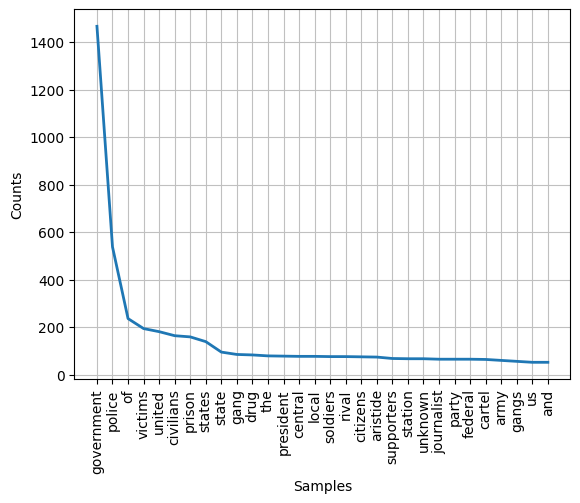

In [ ]:
fdistTrgt.plot(30, cumulative=False)

<Axes: xlabel='Samples', ylabel='Counts'>

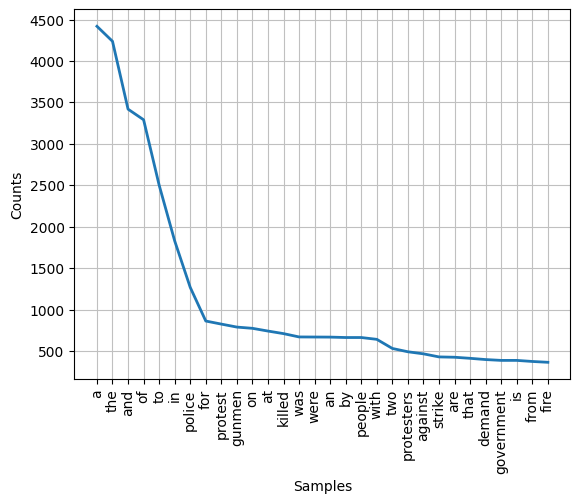

In [ ]:
fdist.plot(30, cumulative=False)


Si el objetivo de la protesta fue el gobierno..... cuales sera los actores y las causas

In [ ]:
dfCausesGovernor = dfCauses[dfCauses['target1'] == 'Government']
dfCausesGovernor.head(10)

,index,eventid,countryname,styr,etype,ndeath,repress,issue1,issuenote,actor1,actor2,actor3,target1,target2,target1_clean,issuenote_clean
18,18,400019,Cuba,1993,4,0,0,10,Cojimar residents hurled stones and shouted an...,Citizens,NaN,NaN,Government,NaN,government,cojimar residents hurled stones and shouted an...
21,21,400022,Cuba,1993,4,0,0,3,Citizens have stoned state stores and attempte...,Citizens,NaN,NaN,Government,NaN,government,citizens have stoned state stores and attempte...
22,22,400023,Cuba,1993,2,0,0,10,Citizens demonstrated the killings of Cubans t...,Citizens,NaN,NaN,Government,NaN,government,citizens demonstrated the killings of cubans t...
25,25,400026,Cuba,1993,2,0,1,10,Demonstrations against government broke out at...,Citizens,NaN,NaN,Government,NaN,government,demonstrations against government broke out at...
28,28,400029,Cuba,1994,8,0,0,10,Group claims to have infiltrated Cuban militar...,PUND paramilitary group,NaN,NaN,Government,NaN,government,group claims to have infiltrated cuban militar...
33,33,400034,Cuba,1994,4,1,2,10,"Demonstrators rioted, clashed with government ...",Citizens,NaN,NaN,Government,Communist Party militants,government,demonstrators rioted clashed with government s...
34,34,400035,Cuba,1994,8,1,0,10,"Citizens hijacked a navy boat to flee to U.S.,...",Hijackers,NaN,NaN,Government,NaN,government,citizens hijacked a navy boat to flee to us 4 ...
40,40,400041,Cuba,1995,1,0,0,10,Exiles flew over Havana distributing leaflets ...,U.S.-based Cuban exiles belonging to group Bro...,NaN,NaN,Government,NaN,government,exiles flew over havana distributing leaflets ...
42,42,400043,Cuba,1996,1,0,0,10,Exiles flew over Havana distributing leaflets ...,U.S.-based Cuban exiles belonging to group Bro...,NaN,NaN,Government,NaN,government,exiles flew over havana distributing leaflets ...
43,43,400044,Cuba,1996,1,0,0,10,Exiles flew over Havana distributing leaflets ...,U.S.-based Cuban exiles belonging to group Bro...,NaN,NaN,Government,NaN,government,exiles flew over havana distributing leaflets ...


In [ ]:
dfCausesGovernor.countryname.unique()

array(['Cuba', 'Haiti', 'Dominican Republic', 'Jamaica',
       'Trinidad and Tobago', 'Mexico', 'Guatemala', 'Honduras',
       'El Salvador', 'Nicaragua', 'Costa Rica', 'Panama'], dtype=object)

In [ ]:
#Conteo de conflictos donde el objetivo ha sido el gobierno
dfCausesGovernorCount = dfCausesGovernor.groupby(['countryname','styr'])['eventid'].count().reset_index()
dfCausesGovernorCount = dfCausesGovernorCount.reset_index()
dfCausesGovernorCount=dfCausesGovernorCount.rename(columns={'eventid':'conlictsPerYear', 'countryname':'Country', 'styr':'year'})


In [ ]:
fig = px.scatter(dfCausesGovernorCount, x= "year", y="conlictsPerYear", color="Country", hover_name="Country")
fig.update_layout(
    title = "Numero de conflictos por pais y año que han sido vinculados a Government",
    xaxis_title="Year",
    yaxis_title="Number of Conflicts",
    legend_title="Country/Region"
)
filePathHtml = f"Conflictos_pais_Goverment.html"
fig.write_html(filePathHtml)
fig.show()

In [ ]:
dfMexico = df[df['countryname']=='Mexico'].reset_index(drop=True)


In [ ]:
dfMexico.head()

,eventid,id,ccode,countryname,startdate,enddate,duration,stday,stmo,styr,...,nsource,notes,female_event,lgbtq_issue,coder,acd_questionable,latitude,longitude,geo_comments,location_precision
0,700001,1,70,Mexico,3-Dec-89,6-Apr-90,125,3,12,1989,...,AP,NaN,0,0,CL,0,19.281590,-101.745300,Centroid of Michoacan State,No
1,700002,2,70,Mexico,8-Jan-90,7-Feb-90,31,8,1,1990,...,AP,Ford fires the striking workers on 2/7/1990.,0,0,CL,0,19.672180,-99.180969,NaN,NaN
2,700003,3,70,Mexico,1-Feb-90,15-Feb-90,15,1,2,1990,...,AP,End date is estimated.,0,0,CL,0,28.632999,-106.069100,NaN,NaN
3,700004,4,70,Mexico,27-Feb-90,12-Mar-90,14,27,2,1990,...,AP,End date is estimated.,0,0,CL,0,17.439190,-99.545097,NaN,NaN
4,700005,5,70,Mexico,1-May-90,1-May-90,1,1,5,1990,...,AP,NaN,0,0,CL,0,19.432610,-99.133209,NaN,NaN


In [ ]:
dfMexico['target1'] = dfMexico['target1'].str.lower().str.translate(str.maketrans('', '', string.punctuation))

In [ ]:
dfMexicoCount = dfMexico.groupby(['styr', 'target1'])['eventid'].count().reset_index()
dfMexicoCount=dfMexicoCount.rename(columns={'eventid':'conlictstargetperyear', 'styr':'year', 'target1':'Objetivo'})
dfMexicoCount.head()

,year,Objetivo,conlictstargetperyear
0,1989,michoacan municipal governments,1
1,1990,ford motor company,1
2,1990,government,1
3,1990,guerrero municipal governments,1
4,1990,institutional revolutionary party pri,1


In [ ]:
figure = px.scatter(dfMexicoCount, x= "year", y="conlictstargetperyear", color="Objetivo", hover_name="Objetivo")
figure.update_layout(
    title = "Numero de conflictos por tipo de target por año en Mexico",
    xaxis_title="Año",
    yaxis_title="Numero de conflictos",
    legend_title="Dirigido a..."
)
filePathHtml = f"Conflictos_Mexico.html"
figure.write_html(filePathHtml)
figure.show()

In [ ]:
from IPython.display import display
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

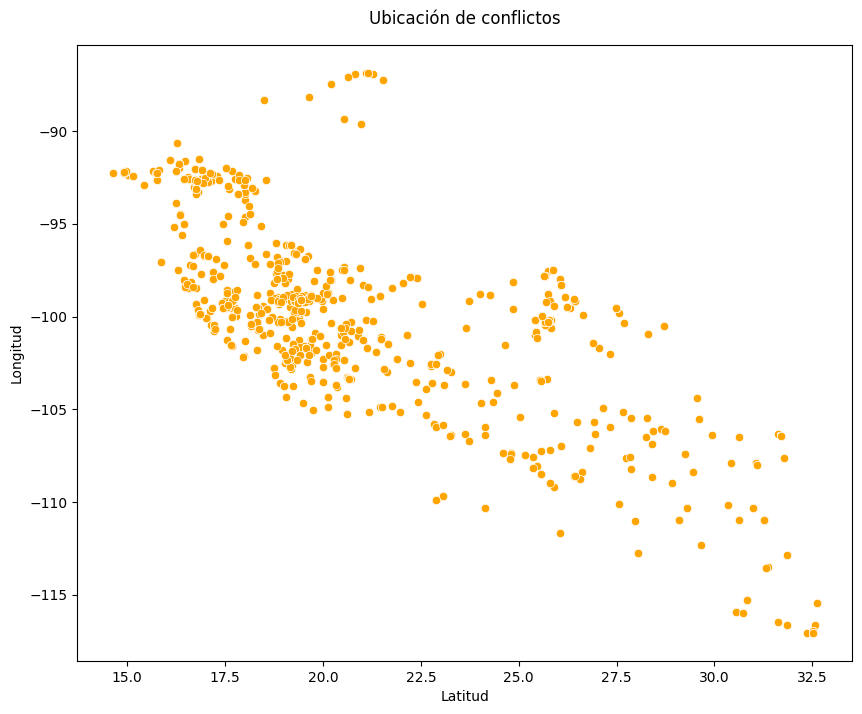

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

ax.set_title('Ubicación de conflictos', pad=15)
ax.set_xlabel('Latitud')
ax.set_ylabel('Longitud')

sns.scatterplot(x='latitude', y='longitude', data=dfMexico, ax=ax, color='orange')
plt.show()

In [ ]:
k_means = KMeans(n_clusters=5, max_iter=10000, n_init='auto')

k_means.fit(dfMexico[['latitude', 'longitude']])

centers = k_means.cluster_centers_

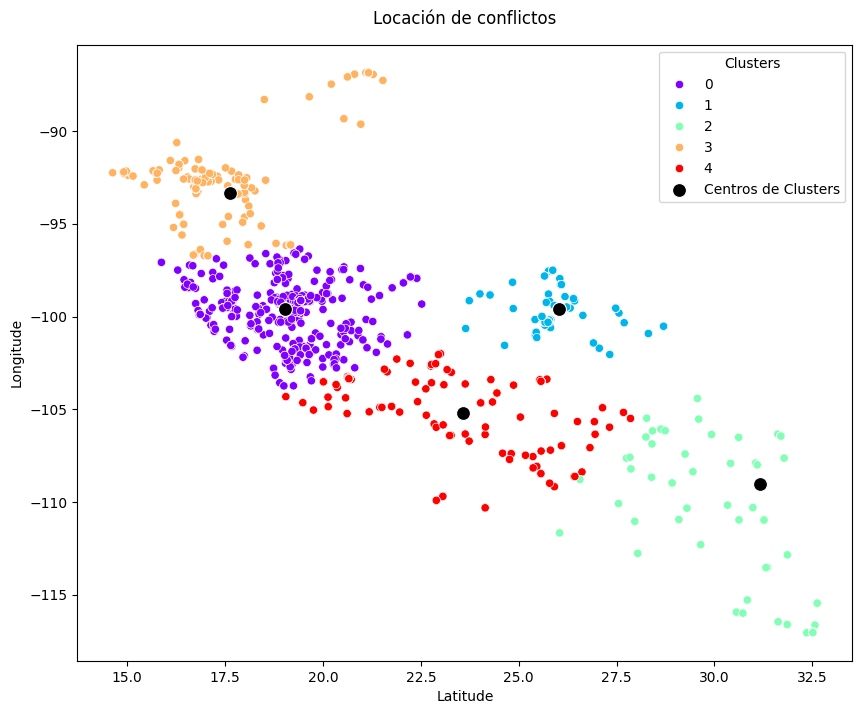

In [ ]:

clasificaciones = k_means.predict(dfMexico[['latitude', 'longitude']])

fig, ax = plt.subplots(figsize=(10, 8))


ax.set_title('Locación de conflictos', pad=15)
ax.set_xlabel('Latitude')
ax.set_ylabel('Longitude')


sns.scatterplot(x='latitude', y='longitude', data=dfMexico, ax=ax, hue=clasificaciones, palette='rainbow')


sns.scatterplot(x=centers[:, 0], y=centers[:, 1], ax=ax, s=100, color='black', label='Centros de Clusters')

ax.legend(title='Clusters')


plt.show()

In [ ]:
def GeolocalizacionYear(year, dataFrame, numberofClusters):
  centers = 0
  try:

    dfMexicoYear = dataFrame[dataFrame['styr'] == year]
    k_means = KMeans(n_clusters=numberofClusters, max_iter=10000, n_init='auto')
    k_means.fit(dfMexicoYear[['latitude', 'longitude']])
    centers = k_means.cluster_centers_
    clasificaciones = k_means.predict(dfMexicoYear[['latitude', 'longitude']])
    print(centers)
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.set_title(f'Locación de conflictos en el {year}', pad=15)
    ax.set_xlabel('Latitude')
    ax.set_ylabel('Longitude')
    sns.scatterplot(x='latitude', y='longitude', data=dfMexicoYear, ax=ax, hue=clasificaciones, palette='rainbow')
    sns.scatterplot(x=centers[:, 0], y=centers[:, 1], ax=ax, s=100, color='black', label='Centros de Clusters')
    ax.legend(title='Clusters')
    plt.show()
  except ValueError:
    pass

  return centers


In [ ]:
dfMexico.head()

,eventid,id,ccode,countryname,startdate,enddate,duration,stday,stmo,styr,...,nsource,notes,female_event,lgbtq_issue,coder,acd_questionable,latitude,longitude,geo_comments,location_precision
0,700001,1,70,Mexico,3-Dec-89,6-Apr-90,125,3,12,1989,...,AP,NaN,0,0,CL,0,19.281590,-101.745300,Centroid of Michoacan State,No
1,700002,2,70,Mexico,8-Jan-90,7-Feb-90,31,8,1,1990,...,AP,Ford fires the striking workers on 2/7/1990.,0,0,CL,0,19.672180,-99.180969,NaN,NaN
2,700003,3,70,Mexico,1-Feb-90,15-Feb-90,15,1,2,1990,...,AP,End date is estimated.,0,0,CL,0,28.632999,-106.069100,NaN,NaN
3,700004,4,70,Mexico,27-Feb-90,12-Mar-90,14,27,2,1990,...,AP,End date is estimated.,0,0,CL,0,17.439190,-99.545097,NaN,NaN
4,700005,5,70,Mexico,1-May-90,1-May-90,1,1,5,1990,...,AP,NaN,0,0,CL,0,19.432610,-99.133209,NaN,NaN


In [ ]:
years = list(dfMexico.styr.unique())
print(years)

[np.int64(1989), np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017)]


[[  18.976484   -99.4290568]
 [  28.632999  -106.0691   ]
 [  30.981951  -110.3006   ]
 [  24.80525   -107.3834   ]]


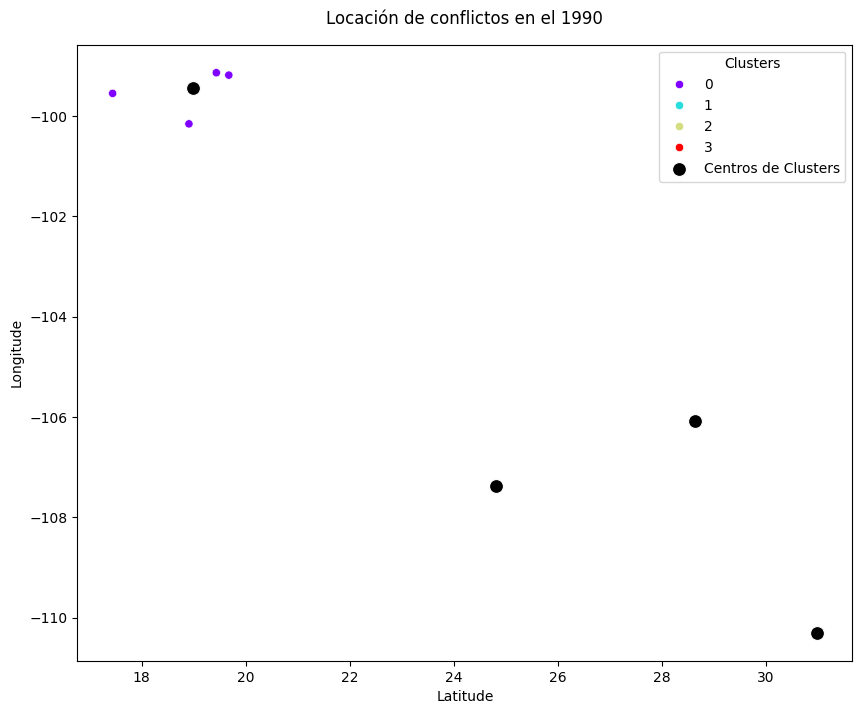

[[  22.11845283 -102.09981667]
 [  17.7736105   -94.58128   ]
 [  25.86903     -97.502739  ]
 [  19.43261     -99.133209  ]]


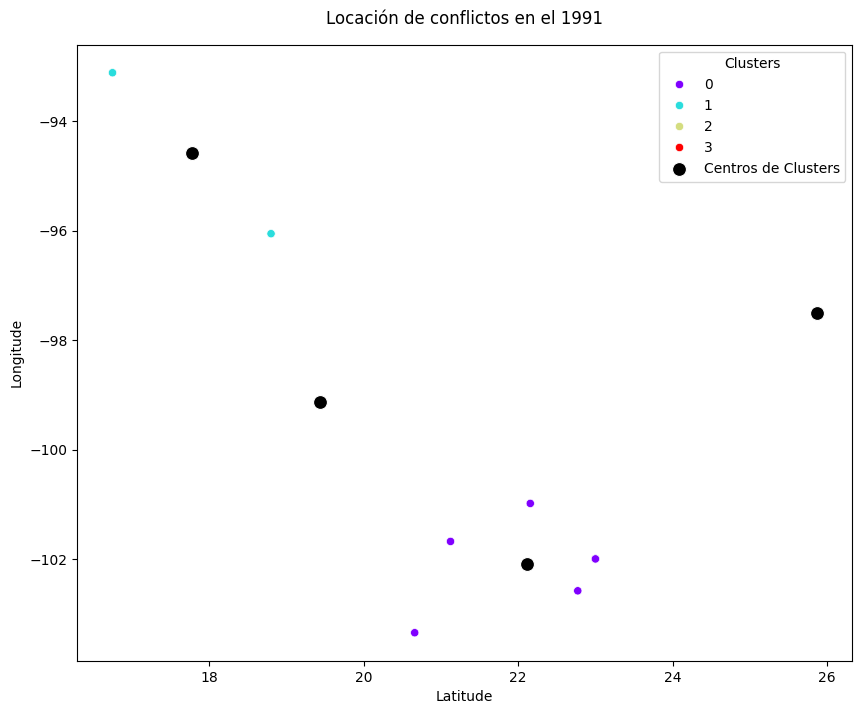

[[  31.697531   -106.4432    ]
 [  19.4963241   -98.6565184 ]
 [  21.68512275 -104.828225  ]
 [  30.84063    -115.2838    ]]


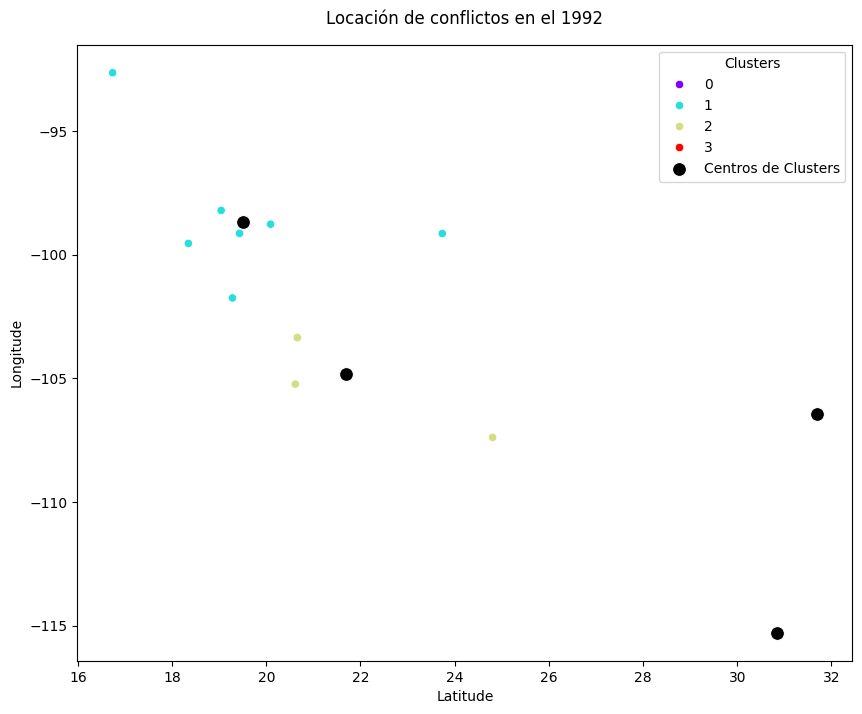

[[  19.45845183  -99.98375225]
 [  29.80739    -107.81933333]
 [  18.815419    -89.223637  ]
 [  25.67321    -100.3092    ]]


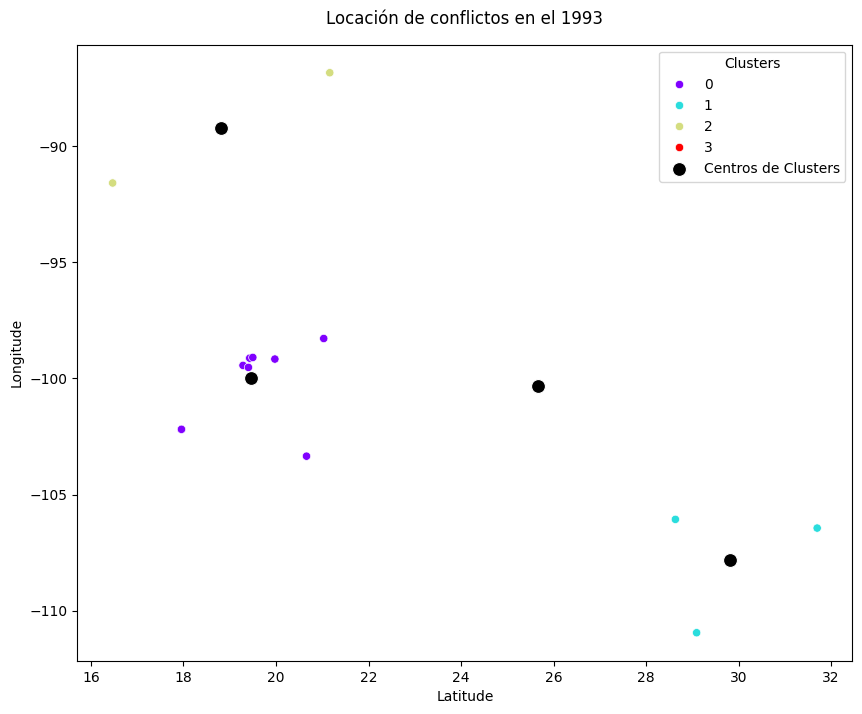

[[  19.29022286  -99.16262957]
 [  32.51495    -117.0382    ]
 [  16.49773671  -92.35306971]
 [  23.4325178  -101.3907    ]]


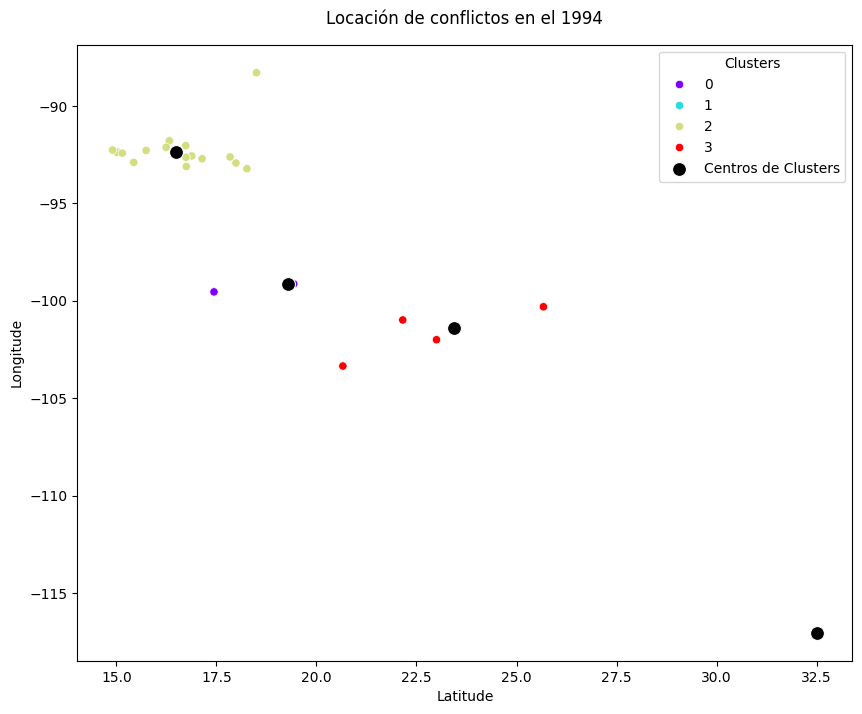

[[  19.57798282  -99.16797236]
 [  16.74320333  -92.6123045 ]
 [  22.26500067 -101.7092    ]
 [  17.5842778   -98.4226022 ]]


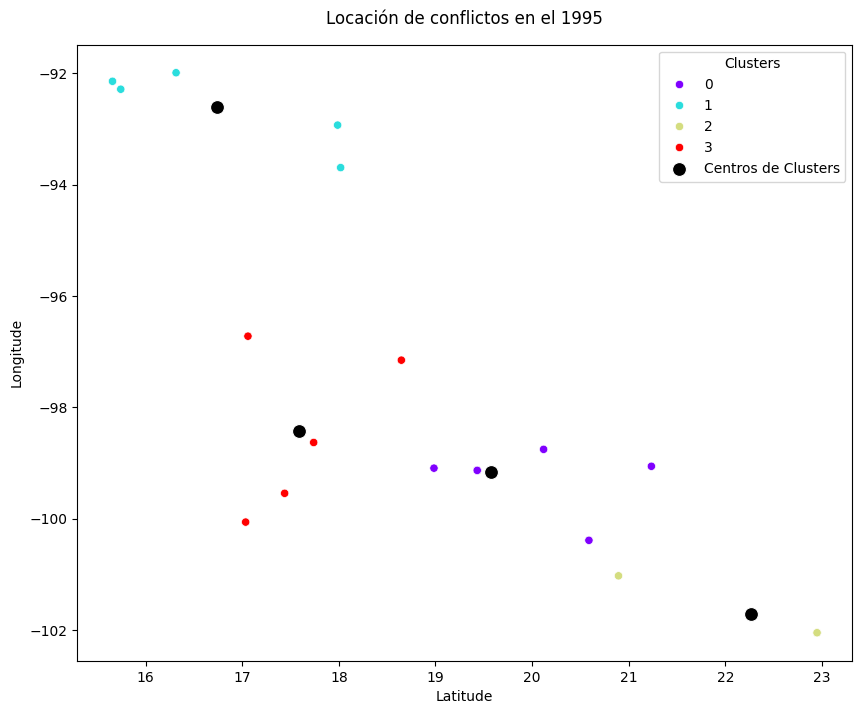

[[  19.21510295  -99.39836176]
 [  32.51495    -117.0382    ]
 [  17.38312825  -92.79189   ]
 [  25.816669   -100.1667    ]]


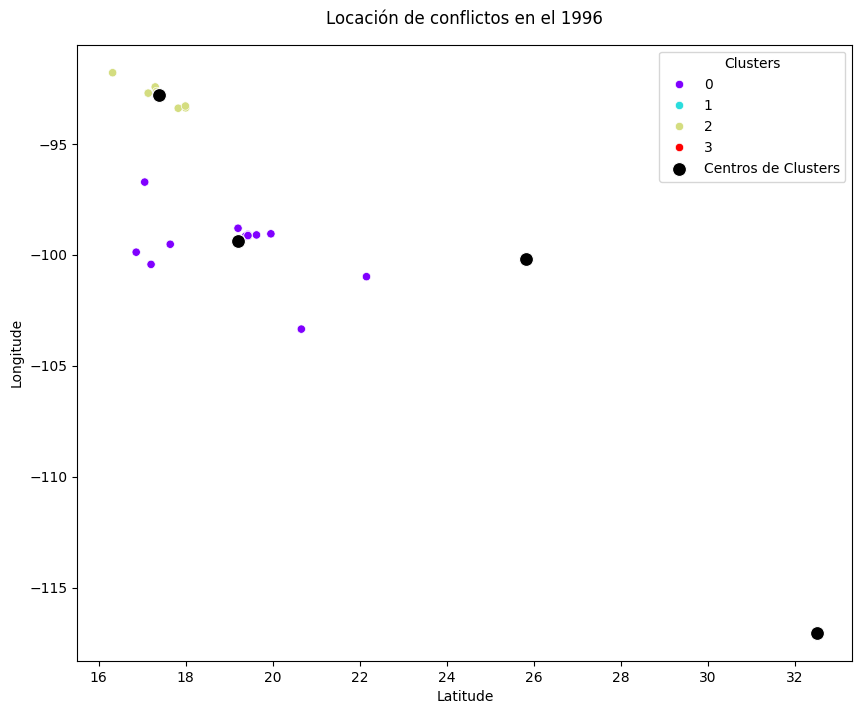

[[  19.80878897  -99.49488044]
 [  31.7987125  -115.85365   ]
 [  17.04694912  -92.62724825]
 [  30.88747057 -107.03297143]]


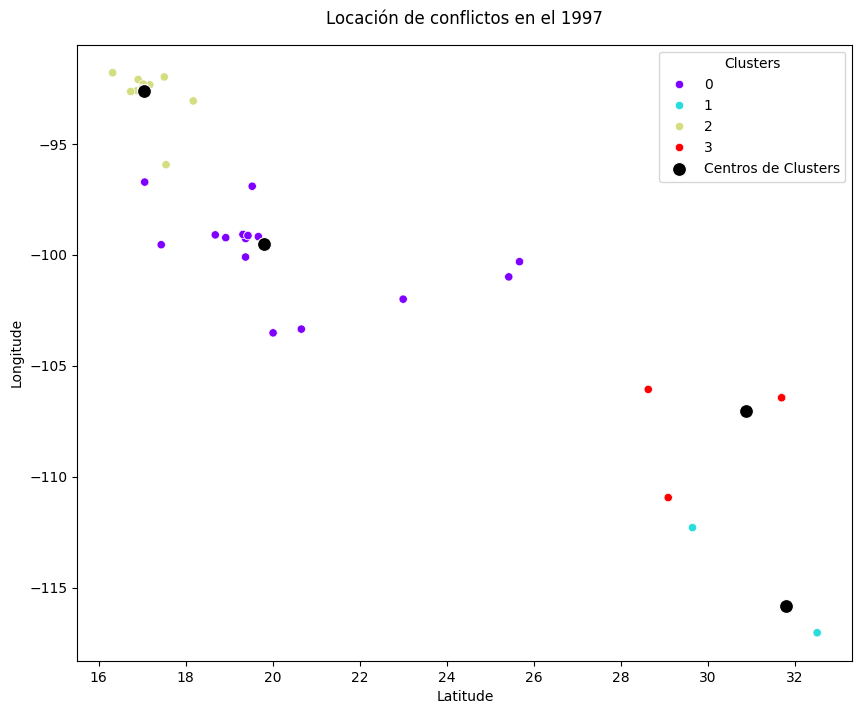

[[  23.66277571 -103.60845714]
 [  16.97065411  -92.42573244]
 [  32.1467525  -114.2815    ]
 [  18.9164244   -99.16234527]]


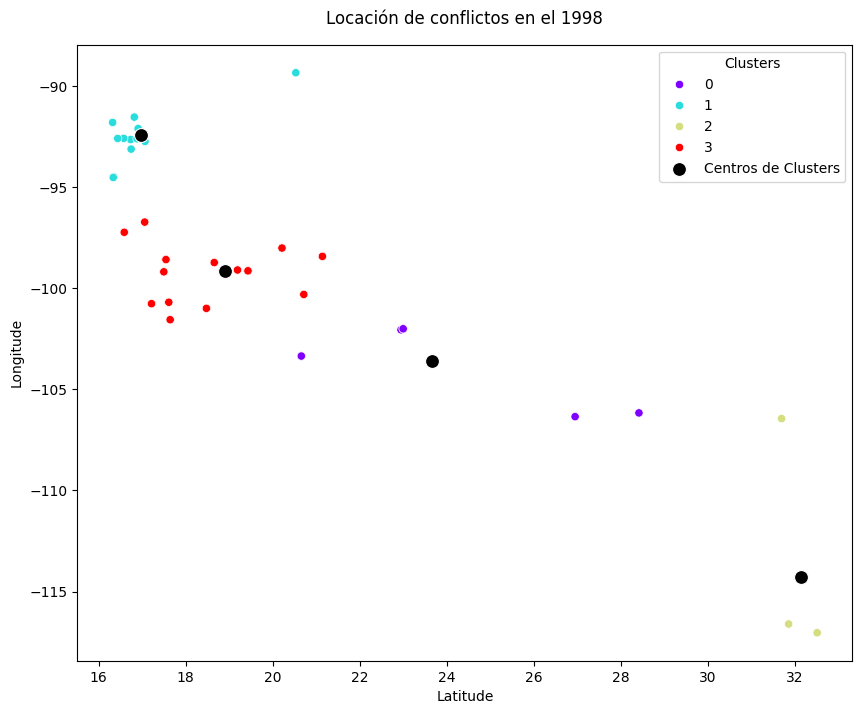

[[  17.40409     -92.76355083]
 [  23.067513   -102.9188    ]
 [  18.98278336  -99.14464039]
 [  31.9152935  -108.991075  ]]


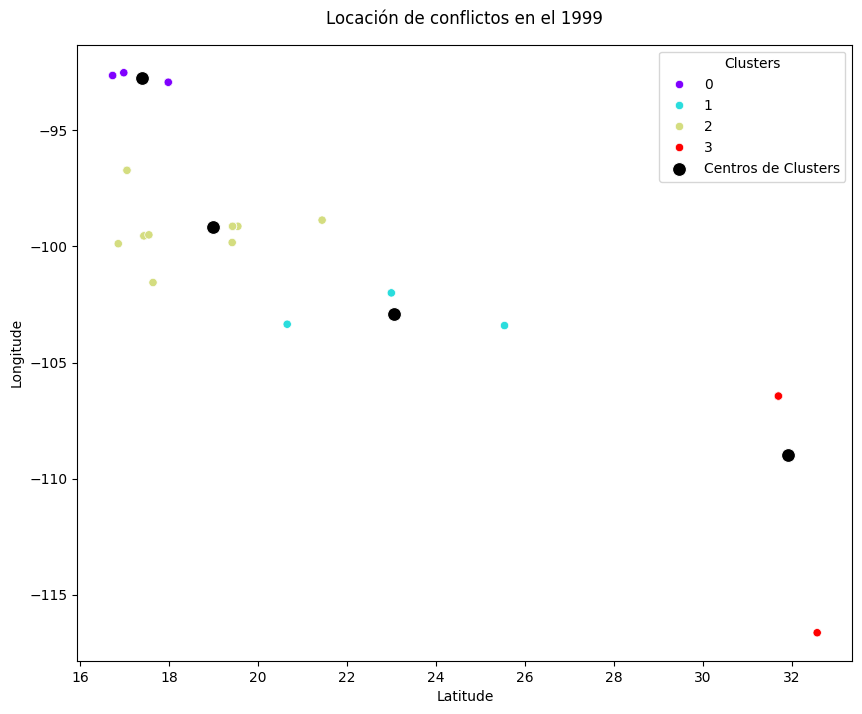

[[  24.69106    -103.6824966 ]
 [  32.35110725 -116.93025   ]
 [  19.48659     -99.14821029]
 [  17.0900684   -92.8570864 ]]


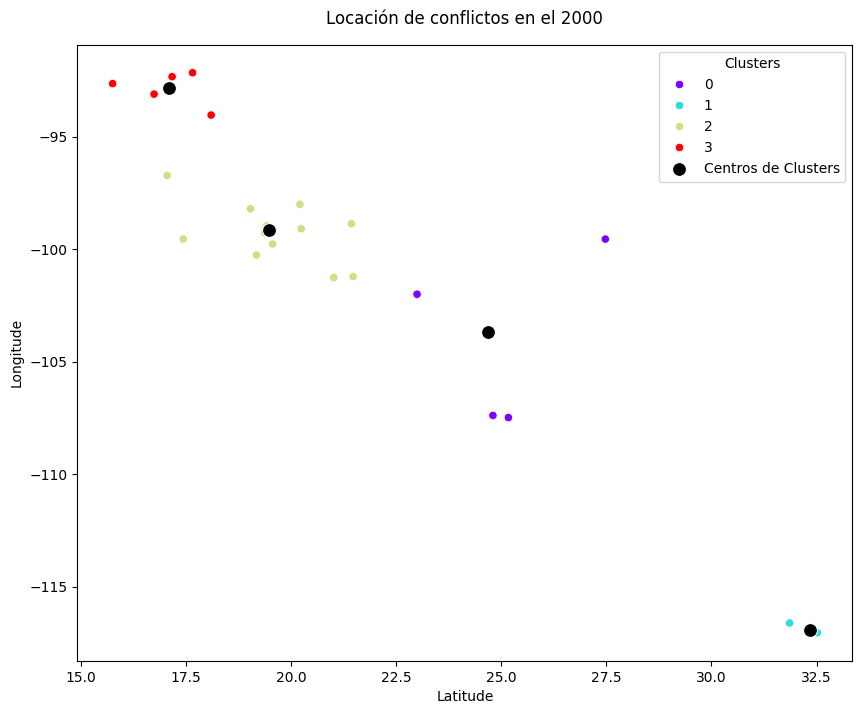

[[  17.35219553  -91.9928242 ]
 [  19.25946815  -99.12787965]
 [  31.55345033 -107.95246667]
 [  22.7641955  -103.7595875 ]]


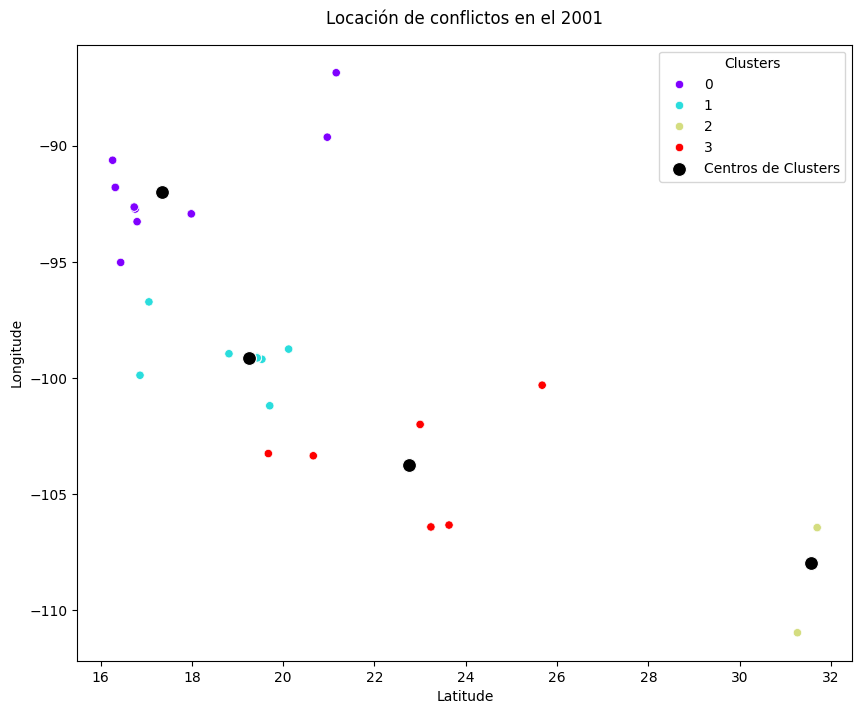

[[  16.55862211  -92.66715656]
 [  25.69835515 -103.86989869]
 [  19.24906112  -99.202061  ]
 [  32.06347    -115.87443333]]


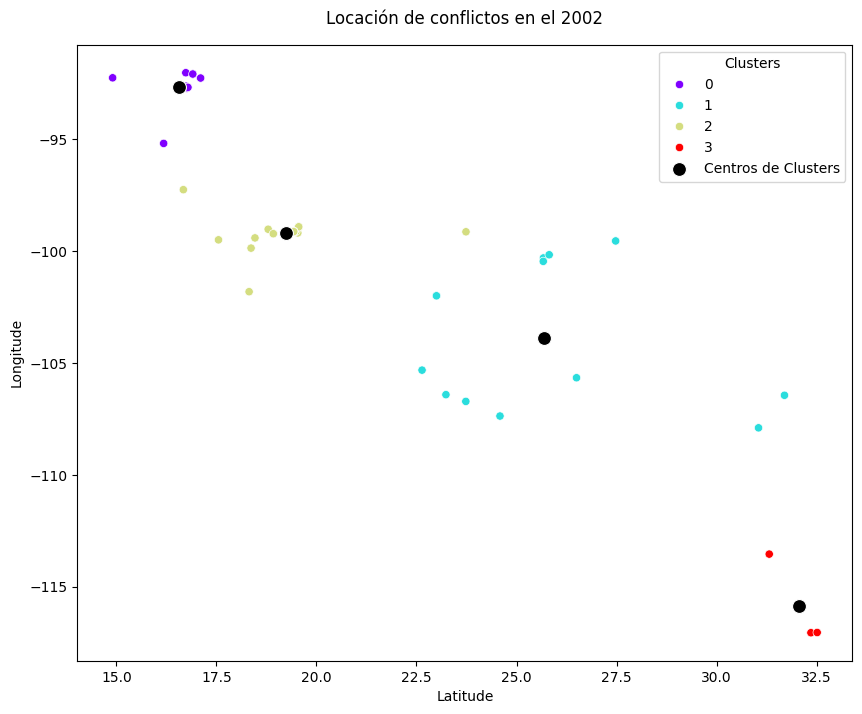

[[  16.199985    -92.53814687]
 [  28.64610775 -109.833025  ]
 [  19.37188145  -99.33251974]
 [  27.47794     -99.549583  ]]


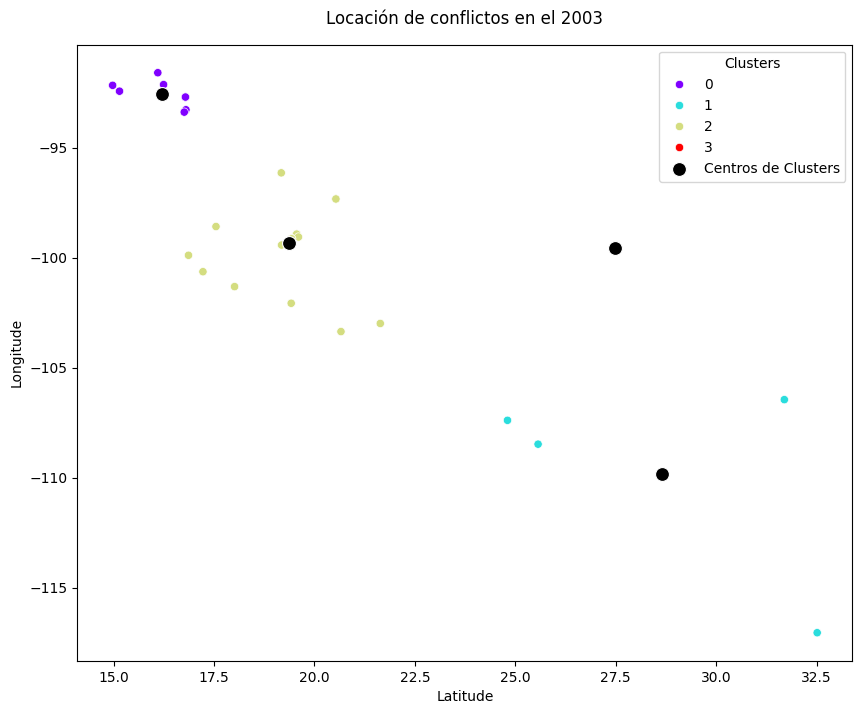

[[  19.56634637  -99.2429312 ]
 [  28.7975026  -107.59076   ]
 [  18.456144    -90.191792  ]
 [  32.51495    -117.0382    ]]


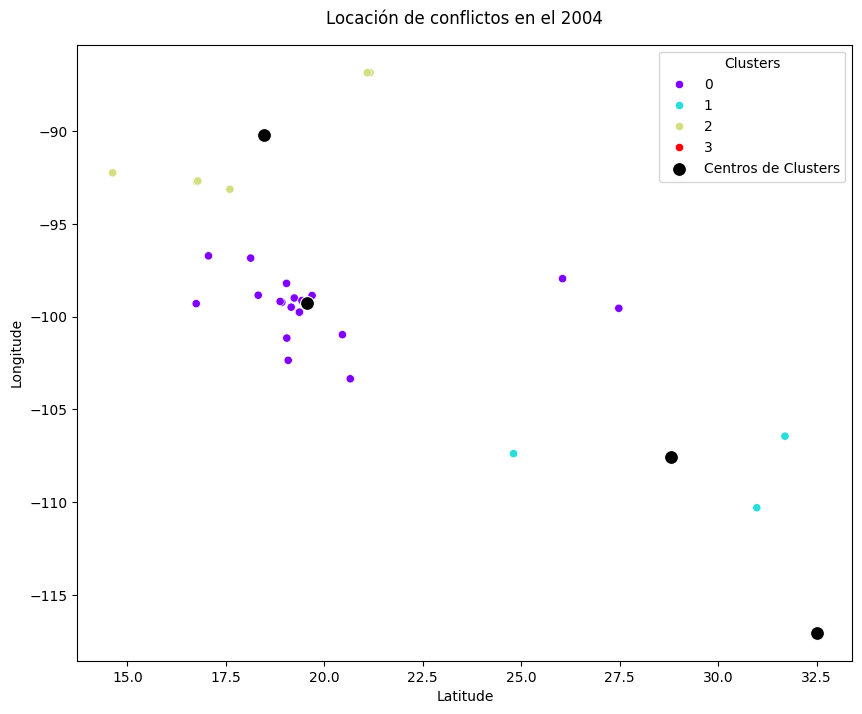

[[  22.89998612 -103.6745875 ]
 [  18.51658653  -98.22536263]
 [  32.49942633 -116.5129    ]
 [  27.75834537 -100.64998933]]


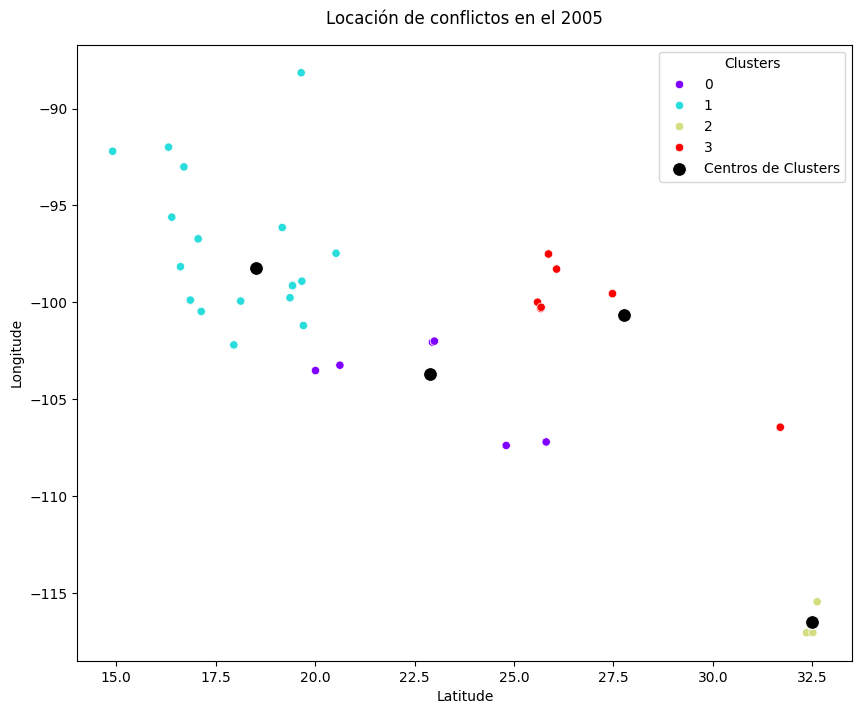

[[  18.84260189  -99.80524041]
 [  26.34132156  -99.97145456]
 [  17.84094433  -94.25717611]
 [  31.8032445  -112.87645   ]]


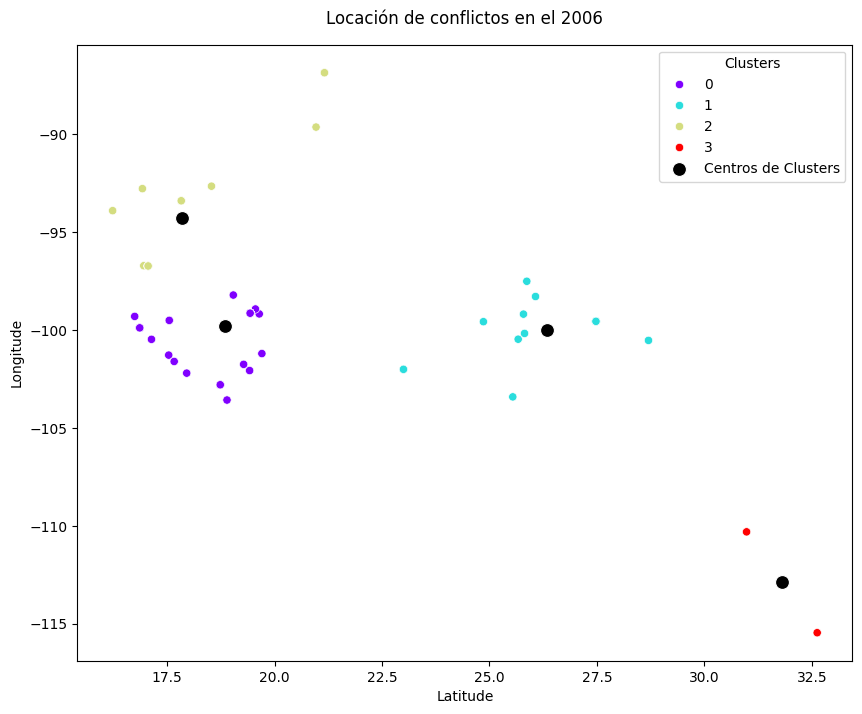

[[  25.2015993  -101.30598195]
 [  30.5624934  -112.24544   ]
 [  19.2022404   -93.6427001 ]
 [  18.31696564  -99.12012836]]


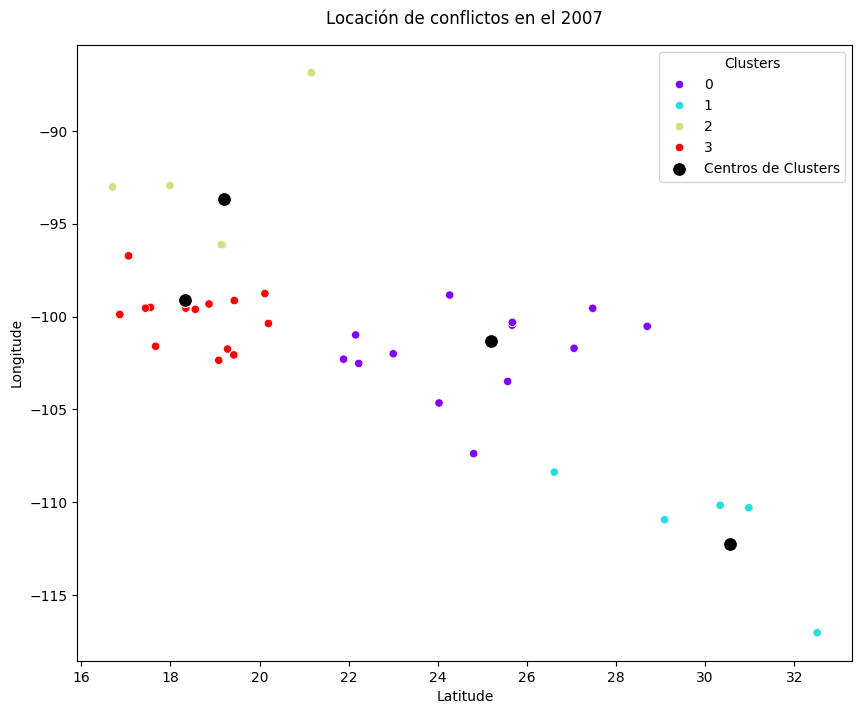

[[  24.99240388 -104.60830688]
 [  31.02803624 -106.67199388]
 [  18.88479114  -98.31228014]
 [  32.5116235  -116.92563571]]


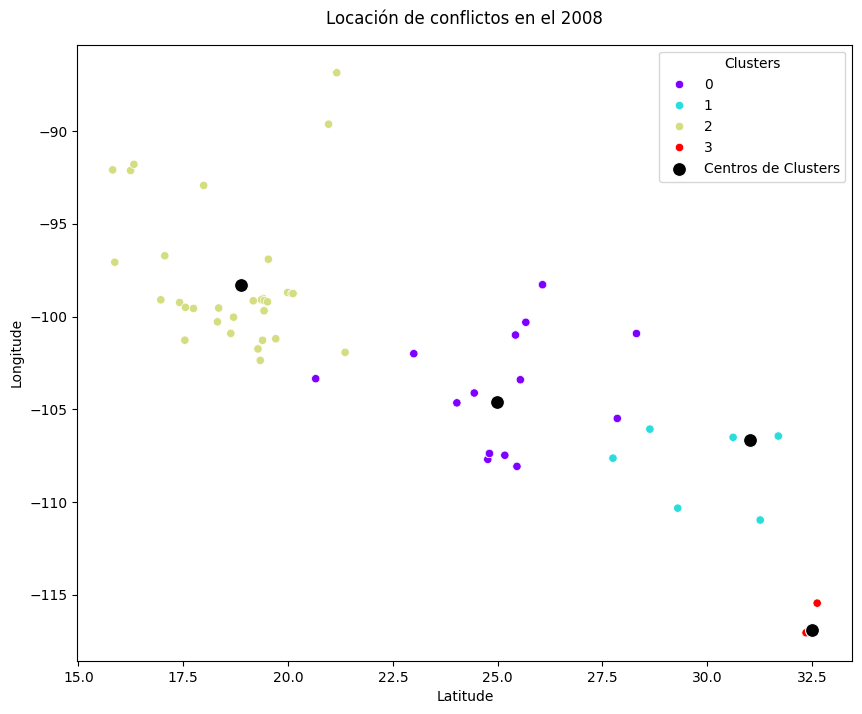

[[  30.61845506 -106.71024328]
 [  18.74964491  -99.1478016 ]
 [  25.00423074 -101.89941894]
 [  32.24674777 -116.31124615]]


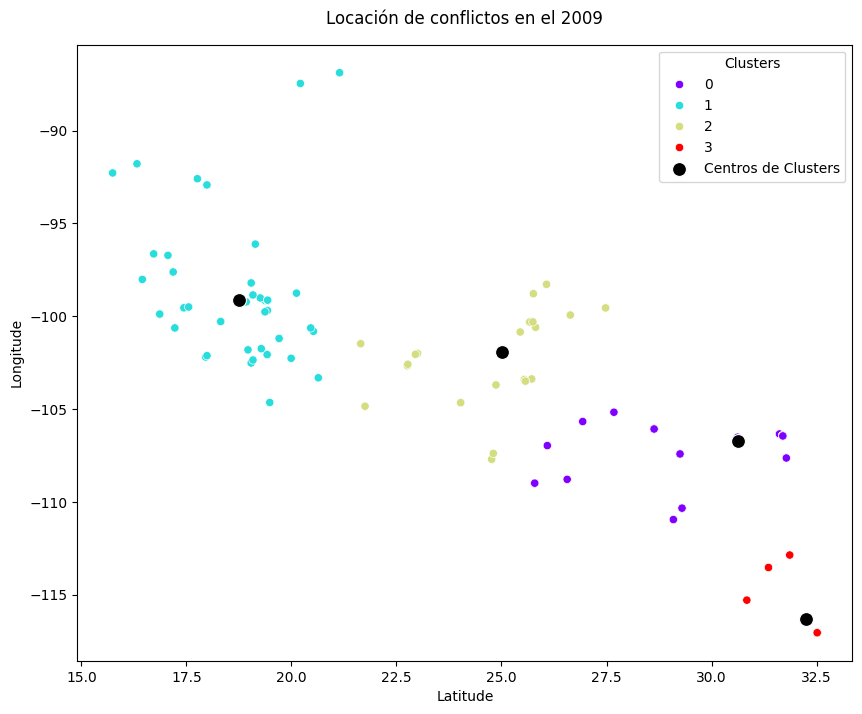

[[  25.66055702  -99.36981294]
 [  31.11068784 -107.087166  ]
 [  18.38836805  -99.20375102]
 [  23.84378069 -104.75994   ]]


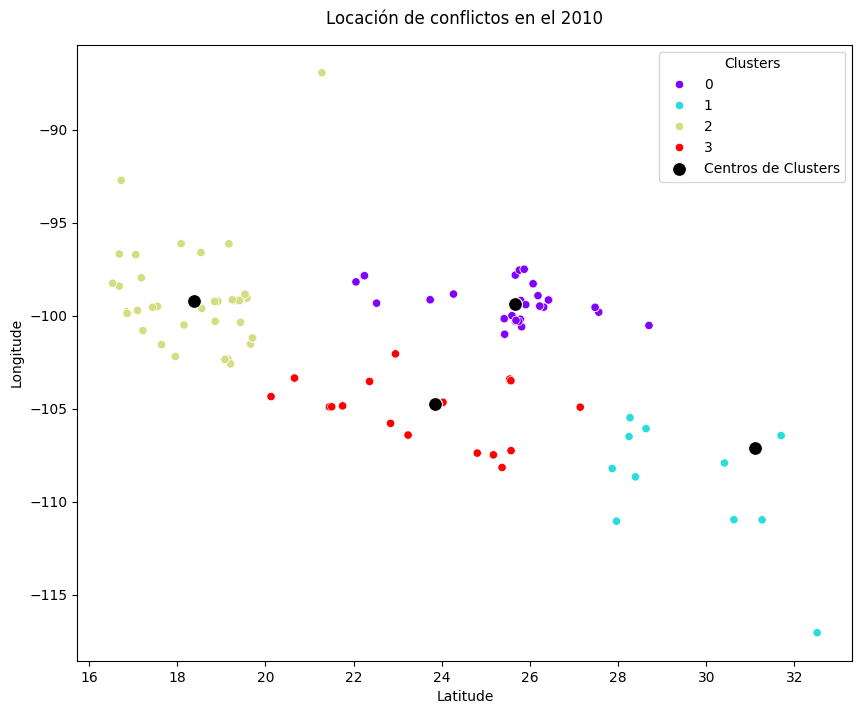

[[  18.86674572  -99.46265378]
 [  31.312231   -106.51668519]
 [  25.17262668 -100.91161345]
 [  26.15970162 -108.78724615]]


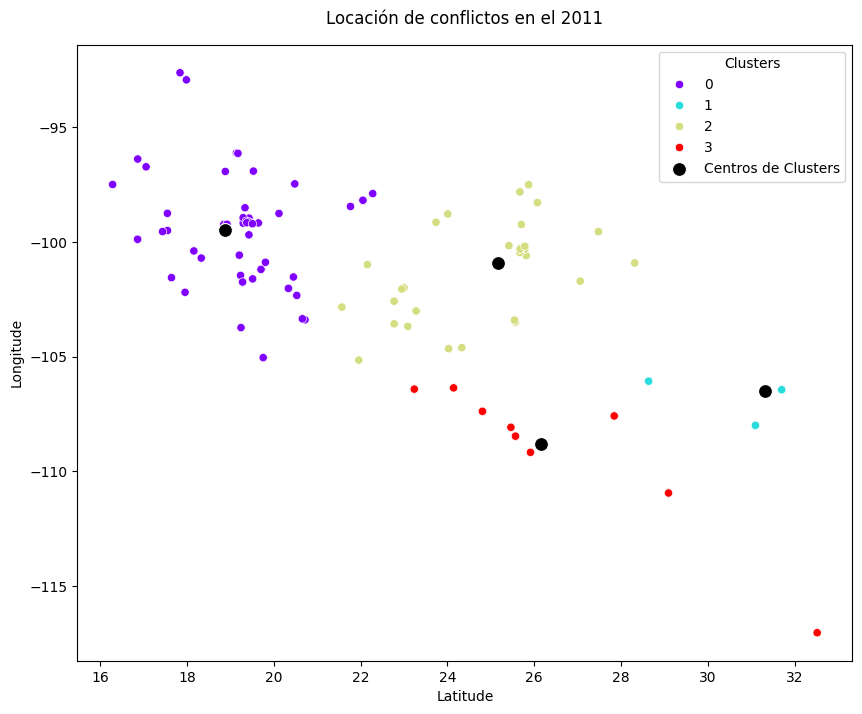

[[  16.92138367  -92.34448867]
 [  26.11643396 -100.58006289]
 [  19.38830349 -100.02152685]
 [  27.54731214 -107.67651429]]


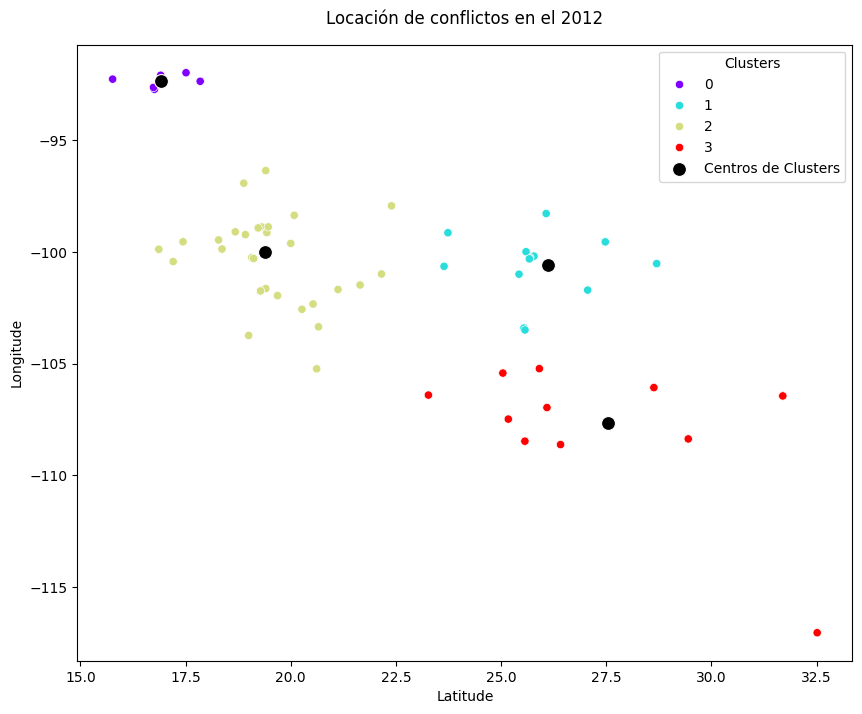

[[  25.41644918  -97.731335  ]
 [  19.32424258  -99.92120732]
 [  29.45978467 -105.76598333]
 [  25.79641436 -108.12563636]]


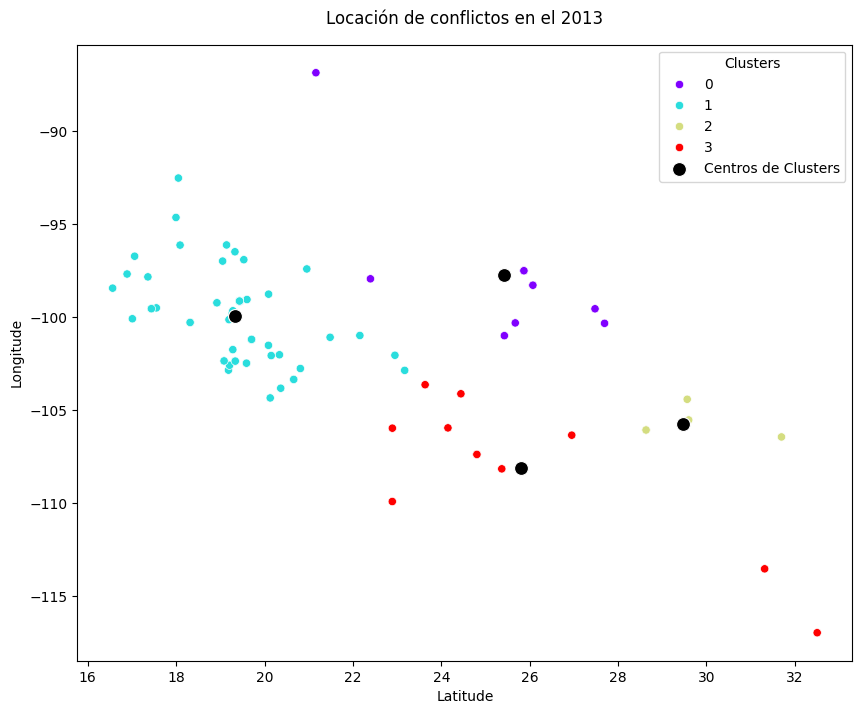

[[  19.14704081  -99.97662711]
 [  32.51495    -117.0382    ]
 [  25.43889941 -101.70223388]
 [  19.81643667  -89.082507  ]]


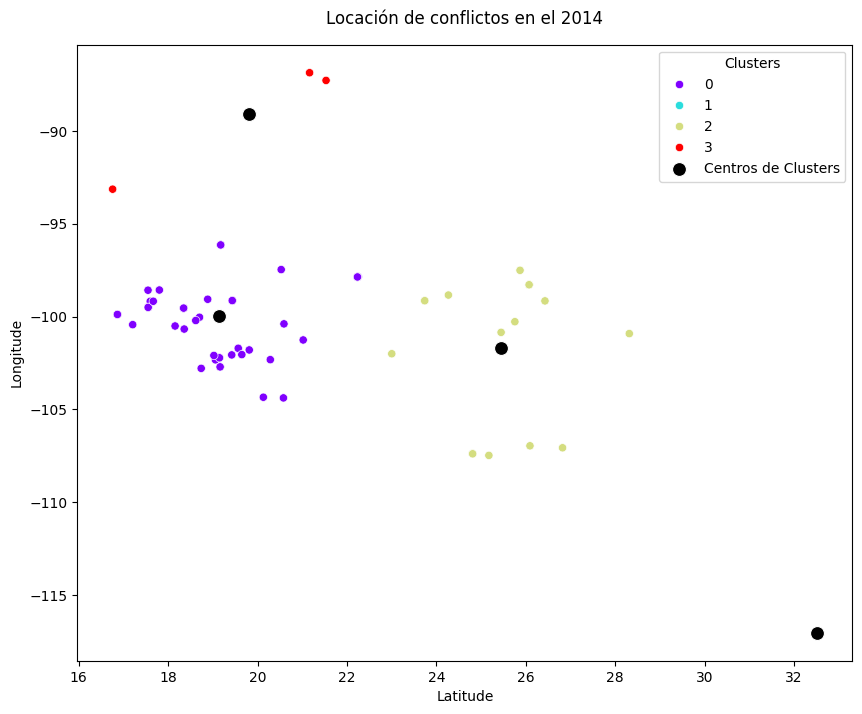

[[  22.32814889 -104.97131111]
 [  18.37988427  -98.62634129]
 [  25.51604556  -98.05691775]
 [  29.05539967 -114.51396667]]


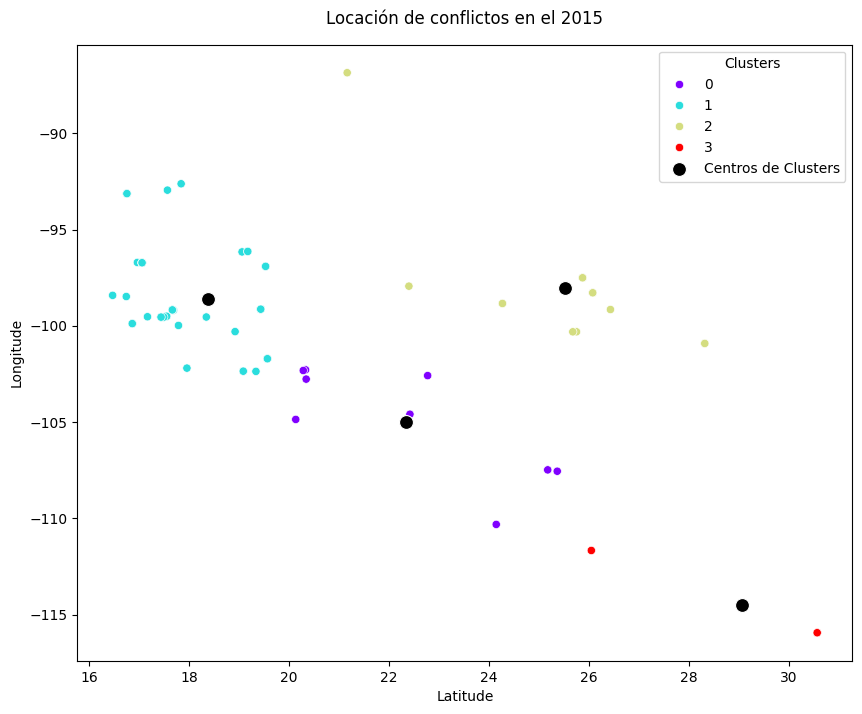

[[  18.18384615  -97.96610945]
 [  28.56513092 -109.503     ]
 [  20.9106253  -102.6682    ]
 [  25.27523716  -99.44586742]]


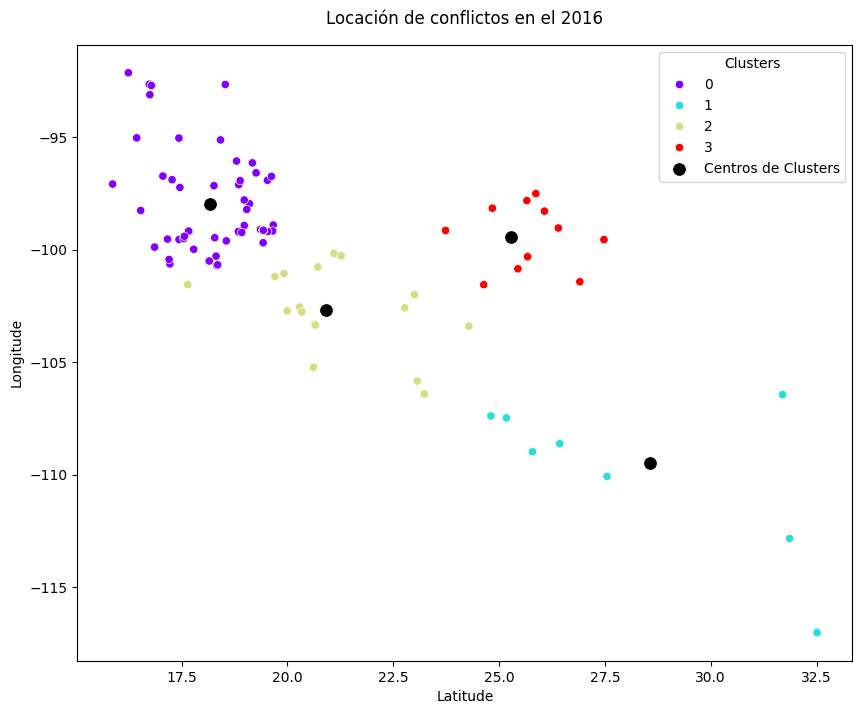

[[  23.98819925 -100.66313825]
 [  18.72486906  -99.00743984]
 [  26.1642086  -109.113792  ]
 [  20.702526    -87.482972  ]]


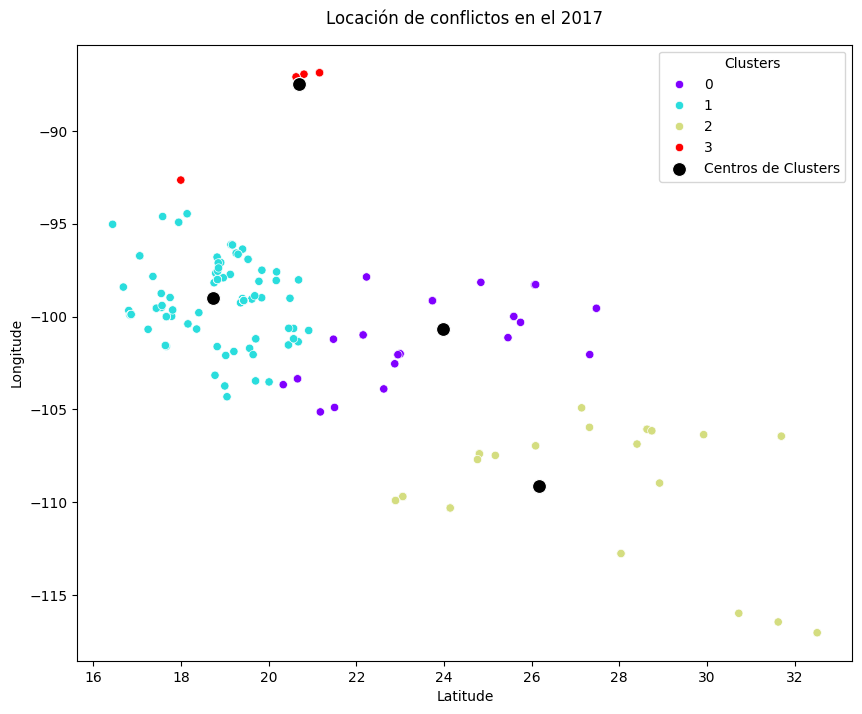

In [ ]:
centersAnalysis = {}

for year in years:
  centers = GeolocalizacionYear(year, dfMexico,4)
  centersAnalysis[year] = centers


In [ ]:
centersAnalysis

{np.int64(1989): 0,
 np.int64(1990): array([[  18.976484 ,  -99.4290568],
        [  28.632999 , -106.0691   ],
        [  30.981951 , -110.3006   ],
        [  24.80525  , -107.3834   ]]),
 np.int64(1991): array([[  22.11845283, -102.09981667],
        [  17.7736105 ,  -94.58128   ],
        [  25.86903   ,  -97.502739  ],
        [  19.43261   ,  -99.133209  ]]),
 np.int64(1992): array([[  31.697531  , -106.4432    ],
        [  19.4963241 ,  -98.6565184 ],
        [  21.68512275, -104.828225  ],
        [  30.84063   , -115.2838    ]]),
 np.int64(1993): array([[  19.45845183,  -99.98375225],
        [  29.80739   , -107.81933333],
        [  18.815419  ,  -89.223637  ],
        [  25.67321   , -100.3092    ]]),
 np.int64(1994): array([[  19.29022286,  -99.16262957],
        [  32.51495   , -117.0382    ],
        [  16.49773671,  -92.35306971],
        [  23.4325178 , -101.3907    ]]),
 np.int64(1995): array([[  19.57798282,  -99.16797236],
        [  16.74320333,  -92.6123045 ],
  

In [ ]:
lista_para_df = []  # Inicializamos una lista vacía para guardar los datos

# Iteramos sobre cada par (año, centroides) en el diccionario
for year, centers in centersAnalysis.items():

    # Verificamos si el valor es efectivamente un array de NumPy
    # Esto ignora de forma segura la entrada de 1989 que tiene un 0 como valor.
    if isinstance(centers, np.ndarray):

        # Iteramos sobre cada par de coordenadas [lat, lon] dentro del array
        # Usamos enumerate para obtener un 'centro_id' (0, 1, 2, ...)
        for centro_id, coords in enumerate(centers):

            # Creamos un pequeño diccionario para esta fila y lo agregamos a la lista
            lista_para_df.append({
                'year': int(year),  # Convertimos el año a un entero estándar
                'centro_id': centro_id,
                'latitud': coords[0], # El primer elemento es la latitud
                'longitud': coords[1] # El segundo elemento es la longitud
            })

# 3. Creamos el DataFrame final a partir de la lista de diccionarios
df_centros = pd.DataFrame(lista_para_df)

In [ ]:
df_centros

,year,centro_id,latitud,longitud
0,1990,0,18.976484,-99.429057
1,1990,1,28.632999,-106.069100
2,1990,2,30.981951,-110.300600
3,1990,3,24.805250,-107.383400
4,1991,0,22.118453,-102.099817
...,...,...,...,...
107,2016,3,25.275237,-99.445867
108,2017,0,23.988199,-100.663138
109,2017,1,18.724869,-99.007440
110,2017,2,26.164209,-109.113792


In [ ]:
import plotly.express as px

fig = px.scatter_map(dfMexico, lat="latitude", lon="longitude",
                        color_discrete_sequence=["red"], zoom=3, height=500)
fig.update_layout(map_style="open-street-map")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
filePathHtml = f"interactive_map_all_years.html"
fig.write_html(filePathHtml)


fig.show()

In [ ]:
dfCentros = df_centros[df_centros['year'] == 1990]
dfCentros


,year,centro_id,latitud,longitud
0,1990,0,18.976484,-99.429057
1,1990,1,28.632999,-106.069100
2,1990,2,30.981951,-110.300600
3,1990,3,24.805250,-107.383400


In [ ]:
dfCentroslist = list(df_centros.year.unique())

In [ ]:
dfMexico.head()

,eventid,id,ccode,countryname,startdate,enddate,duration,stday,stmo,styr,...,nsource,notes,female_event,lgbtq_issue,coder,acd_questionable,latitude,longitude,geo_comments,location_precision
0,700001,1,70,Mexico,3-Dec-89,6-Apr-90,125,3,12,1989,...,AP,NaN,0,0,CL,0,19.281590,-101.745300,Centroid of Michoacan State,No
1,700002,2,70,Mexico,8-Jan-90,7-Feb-90,31,8,1,1990,...,AP,Ford fires the striking workers on 2/7/1990.,0,0,CL,0,19.672180,-99.180969,NaN,NaN
2,700003,3,70,Mexico,1-Feb-90,15-Feb-90,15,1,2,1990,...,AP,End date is estimated.,0,0,CL,0,28.632999,-106.069100,NaN,NaN
3,700004,4,70,Mexico,27-Feb-90,12-Mar-90,14,27,2,1990,...,AP,End date is estimated.,0,0,CL,0,17.439190,-99.545097,NaN,NaN
4,700005,5,70,Mexico,1-May-90,1-May-90,1,1,5,1990,...,AP,NaN,0,0,CL,0,19.432610,-99.133209,NaN,NaN


In [ ]:
for year in dfCentroslist:
  dfCentros = df_centros[df_centros['year'] == year]
  fig = px.scatter_map(dfCentros, lat="latitud", lon="longitud",
                        color_discrete_sequence=["red"], zoom=3, height=500)
  fig.update_layout(map_style="open-street-map")
  fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
  fig.update_layout(
    title=f"Centers in year {year}",
    mapbox_style="open-street-map",
    margin={"r":0, "t":40, "l":0, "b":0},
    height=600,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)
  filePathHtml = f"interactive_map_{year}.html"
  fig.write_html(filePathHtml)

  fig.show()